In [36]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import geemap
import xarray as xr
import ee
import xee

ee.Authenticate()
ee.Initialize(
    project='learning-466121'
)

In [15]:
map = geemap.Map(basemap='HYBRID', ee_initialize=False)

map

Map(center=[0, 0], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topright', transp…

In [16]:
aoi= map.draw_last_feature.geometry()

In [25]:
# Total Suspended matter function
def calculate_tsm(sentinel_2_image):
    
    # Cloud masking 
    cloud_layer = sentinel_2_image.select('probability')
    cloud_mask = cloud_layer.lt(20)
    
    # Convert to reflectance using scale factor
    reflectance = sentinel_2_image.select('B.*').multiply(0.0001)
    
    # NDWI for water detection
    ndwi = reflectance.normalizedDifference(['B3', 'B8']).rename('NDWI')
    
    # Extracting water bodies from ndwi
    water_body = ndwi.gt(0.1)
    
    #TSM calculation using Red Band
    tsm = reflectance.expression(
        # formula for tsm calculation
        '8.1429 * red - 6.6837', 
        {
            'red': reflectance.select('B4')
        }
    ).rename('TSM')
    
    # Apply mask and retain date property
    
    final_tsm = (
        tsm
        .updateMask(cloud_mask)
        .updateMask(water_body)
        .copyProperties(sentinel_2_image, ['system:time_start'])
    )
    return final_tsm

In [26]:
# Load sentinel-2 Imagery
sentinel_2_imegary = (
    ee.ImageCollection("COPERNICUS/S2_SR_HARMONIZED")
    .linkCollection(
        ee.ImageCollection("COPERNICUS/S2_CLOUD_PROBABILITY"),
        'probability'
    )
    .filterDate('2024-01-01', '2025-01-01')
    .filterBounds(aoi)   
    .map(calculate_tsm)
)

In [38]:
def monthly_composites(year):
    months=ee.List.sequence(1,12)
    
    def monthly_image(m):
        start_date = ee.Date.fromYMD(year,m,1)
        end_date = start_date.advance(1, 'month')
        
        monthly_median = (
            sentinel_2_imegary
            .filterDate(start_date, end_date)
            .median()
            .set('system:time_start', start_date.millis())
            .set('month_label', start_date.format('YYYY_MM'))
            
        )
        return monthly_median
    return ee.ImageCollection(months.map(monthly_image))

monthly_tsm_collection = monthly_composites(2024)

In [39]:
# Convert to xarray for time seires Analysis
xr_tsm = xr.open_dataset(
    monthly_tsm_collection,
    engine='ee',
    crs='EPSG:4326',
    scale=0.001,
    geometry=aoi
)
xr_tsm = xr_tsm.sortby('time')



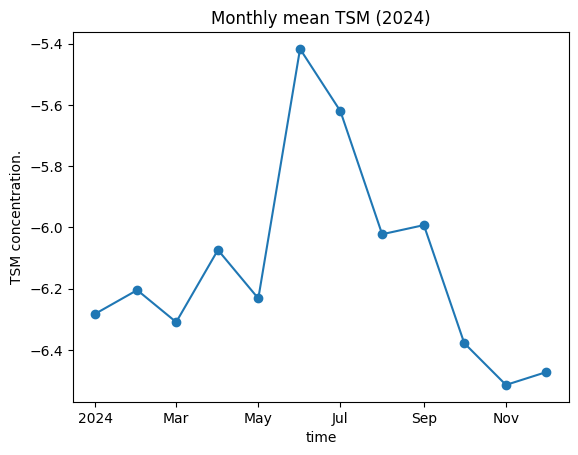

In [41]:
# Calculate time series graph (spatial mean)
mean_tsm_series = xr_tsm.TSM.mean(dim=['lat', 'lon'])

plt.figure()
mean_tsm_series.plot(marker='o')
plt.title('Monthly mean TSM (2024)')
plt.ylabel('TSM concentration.')
plt.savefig('TSM_time_series_2024.png', dpi=300)


In [43]:
# Monthly Geotiff Export 
monthly_list = monthly_tsm_collection.toList(12)

for i in range(12):
    monthly_image =  ee.Image(monthly_list.get(i))
    month_tag = monthly_image.get('month_label').getInfo()
    
    geemap.ee_export_image(
        monthly_image,
        filename=f'TSM_{month_tag}.tif',
        scale=10,
        region=aoi,
        file_per_band=True
    )

Generating URL ...
An error occurred while downloading.
Total request size (262348461 bytes) must be less than or equal to 50331648 bytes.
Generating URL ...
An error occurred while downloading.
Total request size (262348461 bytes) must be less than or equal to 50331648 bytes.
Generating URL ...
An error occurred while downloading.
Total request size (262348461 bytes) must be less than or equal to 50331648 bytes.
Generating URL ...
An error occurred while downloading.
Total request size (262348461 bytes) must be less than or equal to 50331648 bytes.
Generating URL ...
An error occurred while downloading.
Total request size (262348461 bytes) must be less than or equal to 50331648 bytes.
Generating URL ...
An error occurred while downloading.
Total request size (262348461 bytes) must be less than or equal to 50331648 bytes.
Generating URL ...
An error occurred while downloading.
Total request size (262348461 bytes) must be less than or equal to 50331648 bytes.
Generating URL ...
An error

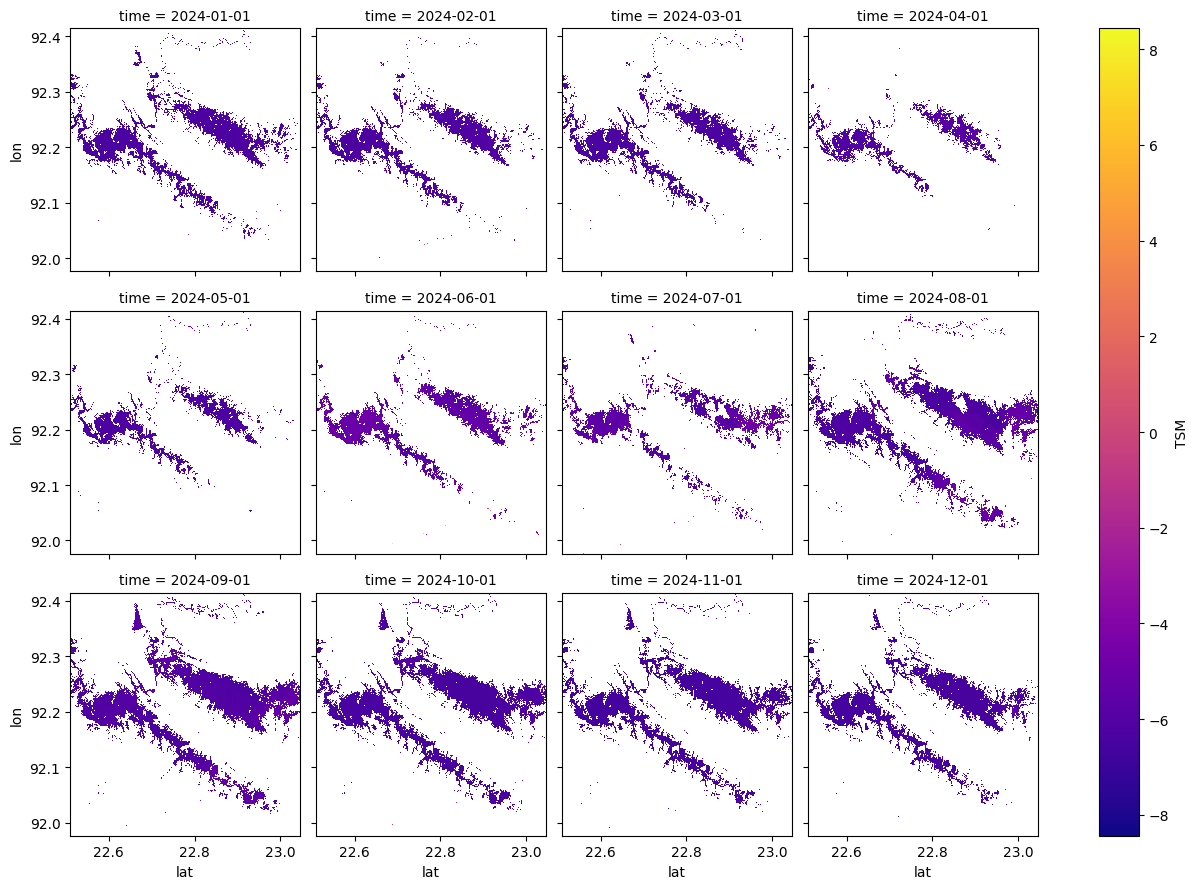

In [46]:
# Total suspended matter map visualization

xr_tsm.TSM.plot(
    col='time', col_wrap=4, cmap='plasma'
)
plt.savefig('TSM_2024.png', dpi=300)